### Loading Dataset from Kegal

In [40]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

filePath = "Salary_Data.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, "mohithsairamreddy/salary-data", filePath
)
print(df.info())
print(df.describe())
print(f"Shape: {df.shape}")
print(f"Null:{df.isnull().sum().sum()}")
print(f"total Duplicates: {df.duplicated().sum().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB
None
               Age  Years of Experience         Salary
count  6702.000000          6701.000000    6699.000000
mean     33.620859             8.094687  115326.964771
std       7.614633             6.059003   52786.183911
min      21.000000             0.000000     350.000000
25%      28.000000             3.000000   70000.000000
50%      32.000000             7.000000  115000.000000
75%      38.000000            12.000000  160000.000000
max      6

In [41]:
print(df["Age"].unique())
print(df["Education Level"].unique())
print(df["Job Title"].unique())
print(df['Years of Experience'].unique())
print(df['Salary'].unique())

[32. 28. 45. 36. 52. 29. 42. 31. 26. 38. 48. 35. 40. 27. 44. 33. 39. 25.
 51. 34. 47. 30. 41. 37. 24. 43. 50. 46. 49. 23. 53. nan 61. 57. 62. 55.
 56. 54. 60. 58. 22. 21.]
<StringArray>
[       'Bachelor's',          'Master's',               'PhD',
                 nan, 'Bachelor's Degree',   'Master's Degree',
       'High School',               'phD']
Length: 8, dtype: str
<StringArray>
[           'Software Engineer',                 'Data Analyst',
               'Senior Manager',              'Sales Associate',
                     'Director',            'Marketing Analyst',
              'Product Manager',                'Sales Manager',
        'Marketing Coordinator',             'Senior Scientist',
 ...
       'Junior Sales Associate',      'Human Resources Manager',
        'Juniour HR Generalist',       'Juniour HR Coordinator',
 'Digital Marketing Specialist',                 'Receptionist',
           'Marketing Director',                     'Social M',
             'Soc

In [42]:
# Redefining column names
df.rename(
    columns={
        'Years of Experience': 'Experience',
        "Education Level": 'Education',
        'Job Title': 'Job',
    },
    inplace=True,
)
print(df.columns)
print(df['Gender'].unique())
for col in ['Gender', 'Education', 'Job', 'Experience', 'Salary', 'Age']:
    df[col] = df[col].fillna({"unknown": pd.NA, "nan": pd.NA})

Index(['Age', 'Gender', 'Education', 'Job', 'Experience', 'Salary'], dtype='str')
<StringArray>
['Male', 'Female', nan, 'Other']
Length: 4, dtype: str


In [43]:
# categorical data
for col in ['Gender', 'Education', 'Job']:
    df[col] = df[col].astype(str).str.lower().str.strip()
df['Education'] = df['Education'].replace(
    {
        "unknown": pd.NA,
        'nan': pd.NA,
        "bachelor's degree": "bachelor's",
        "master's degree": "master's",
    }
)
# removing extra gender
df['Gender'] = df['Gender'].replace(
    {
        "": pd.NA,
        "nan": pd.NA,
        "unknown": pd.NA,
        "other": pd.NA,
        "femle": "female",
        "malee": "male",
    }
)
for col in ['Gender', 'Education', 'Job', 'Experience']:
    print(df[col].unique())

print(df['Experience'].unique())

<StringArray>
['male', 'female', nan]
Length: 3, dtype: str
<StringArray>
['bachelor's', 'master's', 'phd', nan, 'high school']
Length: 5, dtype: str
<StringArray>
[           'software engineer',                 'data analyst',
               'senior manager',              'sales associate',
                     'director',            'marketing analyst',
              'product manager',                'sales manager',
        'marketing coordinator',             'senior scientist',
 ...
       'junior sales associate',      'human resources manager',
        'juniour hr generalist',       'juniour hr coordinator',
 'digital marketing specialist',                 'receptionist',
           'marketing director',                     'social m',
             'social media man',              'delivery driver']
Length: 193, dtype: str
[5.0 3.0 15.0 7.0 20.0 2.0 12.0 4.0 1.0 10.0 18.0 6.0 14.0 16.0 0.0 22.0
 19.0 9.0 13.0 11.0 25.0 21.0 8.0 17.0 23.0 24.0 0.5 1.5 nan 31.0 30.0
 28.0 33.0 27

c:\Projects\Python\python practice code\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:837: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Projects\Python\python practice code\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:838: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


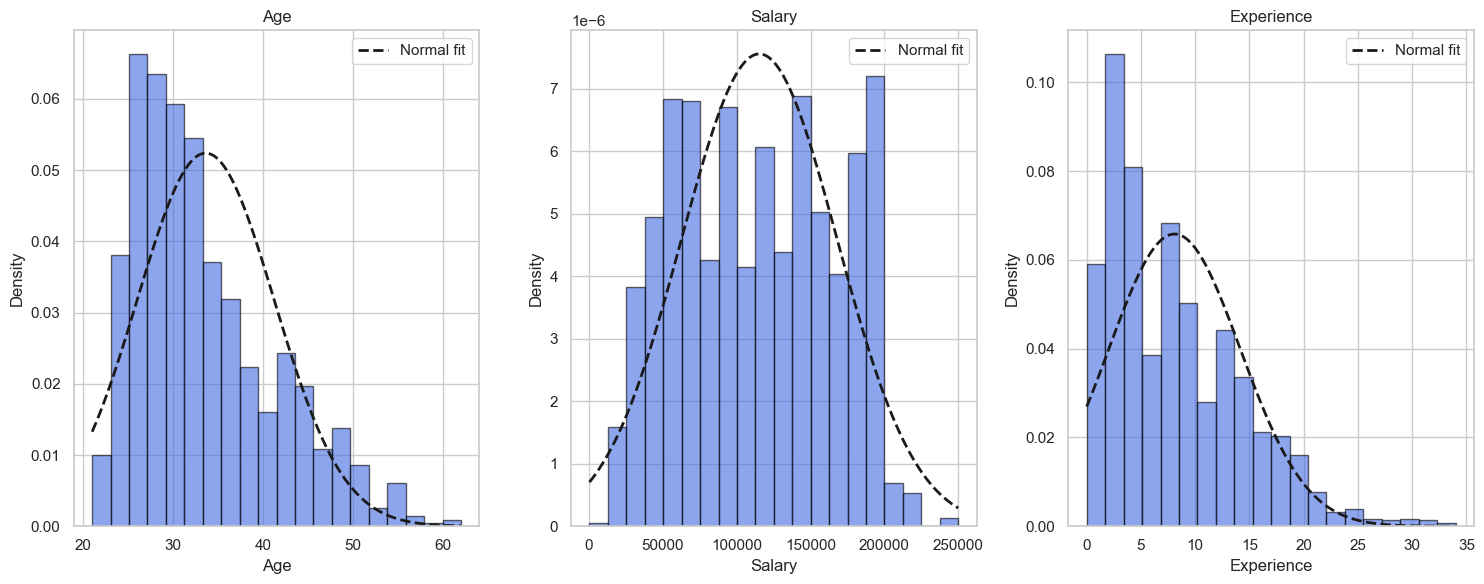

In [44]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for idx, col in enumerate(['Age', 'Salary', 'Experience']):
    axes[idx].hist(
        df[col], bins=20, density=True, alpha=0.6, color='royalblue', edgecolor='black'
    )
    axes[idx].set_title(col)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    # Calculate and plot normal distribution curve
    mu = df[col].mean()
    sigma = df[col].std()
    x = np.linspace(df[col].min(), df[col].max(), 100)
    # using formula for normal dist
    y = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    axes[idx].plot(x, y, 'k--', linewidth=2, label='Normal fit')
    axes[idx].set_title(col)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')  # Changed from 'Frequency' to 'Density'
    axes[idx].legend()
plt.tight_layout()

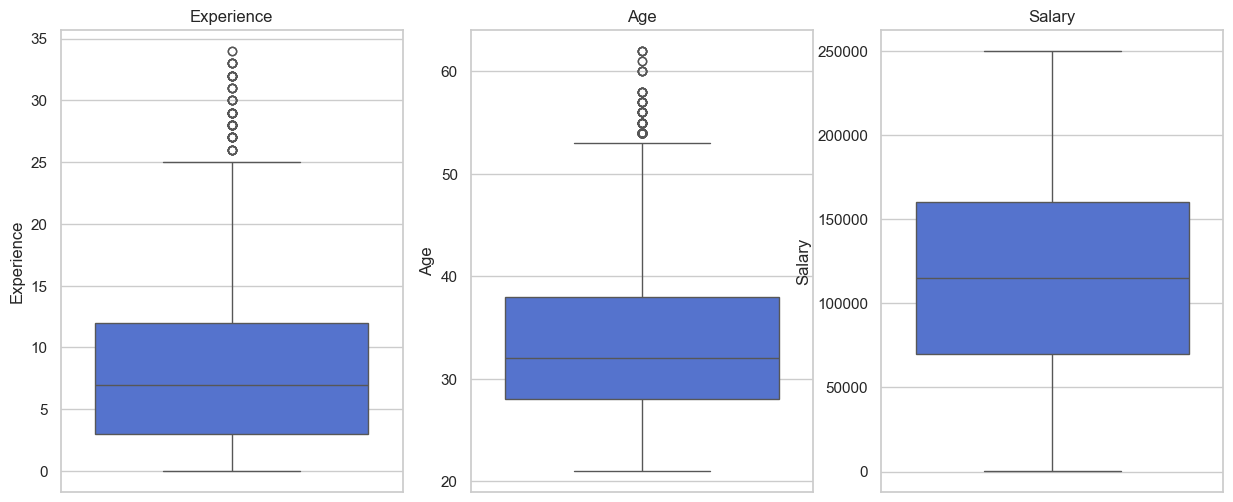

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, col in enumerate(["Experience", "Age", "Salary"], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='royalblue')
    plt.title(col)
plt.show()

In [46]:
# handling dublicate values
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(
    f"Shape before removing duplicates: {df.shape} after removing duplicates: {df_clean.shape}"
)

Shape before removing duplicates: (6704, 6) after removing duplicates: (1791, 6)


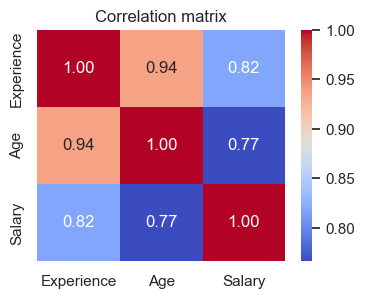

In [47]:
# Pairplot to see relationships
# sns.pairplot(df[["Years of Experience", "Age", "Salary"]])
# plt.show()

# Correlation heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(
    df_clean[
        [
            "Experience",
            "Age",
            "Salary",
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation matrix")
plt.show()

In [48]:
# creating pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

age_pipeline = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
)
##for experience
log_transform = FunctionTransformer(func=np.log1p, validate=False)
skewed_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('log', log_transform),
        ('scaler', StandardScaler()),
    ]
)
gender_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary")),
    ]
)
edu_order = [
    "primary",  # lowest
    "high school",
    "diploma",
    "bachelors",
    "masters",
    "phd",
]
education_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "oridnal",
            OrdinalEncoder(
                categories=[edu_order],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)
job_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False),
        ),
    ]
)

#### strong correlations among these variables experience and age are highly correlated, both relate to salary, which can create multicollinearity issues in linear regression

In [49]:
# numeric_features = ['Age', 'Salary']
# categorical_features = ['Gender', 'Education']
age = ['Age']
education = ['Education']
gender = ['Gender']
skewed = ['Experience']
job = ['Job']
preprocessor = ColumnTransformer(
    transformers=[
        ("age", age_pipeline, age),
        ("education", education_pipeline, education),
        ("gender", gender_pipeline, gender),
        ('skewed', skewed_pipeline, skewed),
        ('job', job_pipeline, job),
    ]
)
median_salary = df_clean['Salary'].median()
df_clean['Salary'] = pd.to_numeric(df_clean['Salary'], errors="coerce").fillna(
    median_salary
)
# log transformation to handle skewness in salary
df_clean['log_salary'] = np.log1p(df_clean['Salary'])

X = df_clean[['Age', 'Gender', 'Education', 'Job', 'Experience']]
Y = df_clean['log_salary']
print(Y.isna().sum())
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"x-train:{X_train.shape}, x-test:{X_test.shape}")
print(f"Y-train:{Y_train.shape}, x-test:{Y_test.shape}")

0
x-train:(1432, 5), x-test:(359, 5)
Y-train:(1432,), x-test:(359,)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

Linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("linear", LinearRegression()),
    ]
)
Ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("ridge", Ridge(alpha=1.8307)),
    ]
)

Polynomial_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linear", LinearRegression()),
    ]
)

Linear_model.fit(X_train, Y_train)
Ridge_model.fit(X_train, Y_train)
Polynomial_model.fit(X_train, Y_train)

y_predict_li = Linear_model.predict(X_test)
y_predict_ri = Ridge_model.predict(X_test)
y_predict_po = Polynomial_model.predict(X_test)
print(f"Linear R2: {r2_score(Y_test, y_predict_li):.3f} ")
print(f"Linear MAE: {mean_absolute_error(Y_test, y_predict_li):.3f}")
print(f"Linear MSE: {mean_squared_error(Y_test, y_predict_li):.3f}")
print(f"Linear RMSE: {root_mean_squared_error(Y_test, y_predict_li):.3f}")
print("-" * 30)
print(f"Ridge  R2: { r2_score(Y_test, y_predict_ri):.3f} ")
print(f"Ridge  MAE: {mean_absolute_error(Y_test, y_predict_ri):.3f}")
print(f"Ridge  RMSE: {root_mean_squared_error(Y_test, y_predict_ri):.3f}")
print("-" * 30)
print(f"Polynomial R2: {r2_score(Y_test, y_predict_po):.3f} ")
print(f"Polynomial MAE: {mean_absolute_error(Y_test, y_predict_po):.3f}")
print(f"Polynomial RMSE: {root_mean_squared_error(Y_test, y_predict_po):.3f}")

Linear R2: 0.893 
Linear MAE: 0.133
Linear MSE: 0.029
Linear RMSE: 0.169
------------------------------
Ridge  R2: 0.890 
Ridge  MAE: 0.136
Ridge  RMSE: 0.172
------------------------------
Polynomial R2: 0.808 
Polynomial MAE: 0.131
Polynomial RMSE: 0.227


In [52]:
print("-" * 30)
sample = pd.DataFrame(
    [
        {
            "Age": 30,
            "Gender": "male",
            "Education": "bachelor's",
            "Job": "software engineer",
            "Experience": 5,
        }
    ]
)

# Predict log-salary, then convert to Salary
sample_log_pred = Linear_model.predict(sample)[0]
sample_salary_pred = np.expm1(sample_log_pred)


print(f"Predicted Salary for sample Linear Regression: ${sample_salary_pred:,.2f}")
print(
    f"Predicted Salary for sample Ridge Regression: ${np.expm1(Ridge_model.predict(sample)[0]):,.2f}"
)
print(
    f"Predicted Salary for sample Polynomial Regression: ${np.expm1(Polynomial_model.predict(sample)[0]):,.2f}"
)
print("-" * 30)

------------------------------
Predicted Salary for sample Linear Regression: $108,919.93
Predicted Salary for sample Ridge Regression: $108,288.62
Predicted Salary for sample Polynomial Regression: $111,402.67
------------------------------


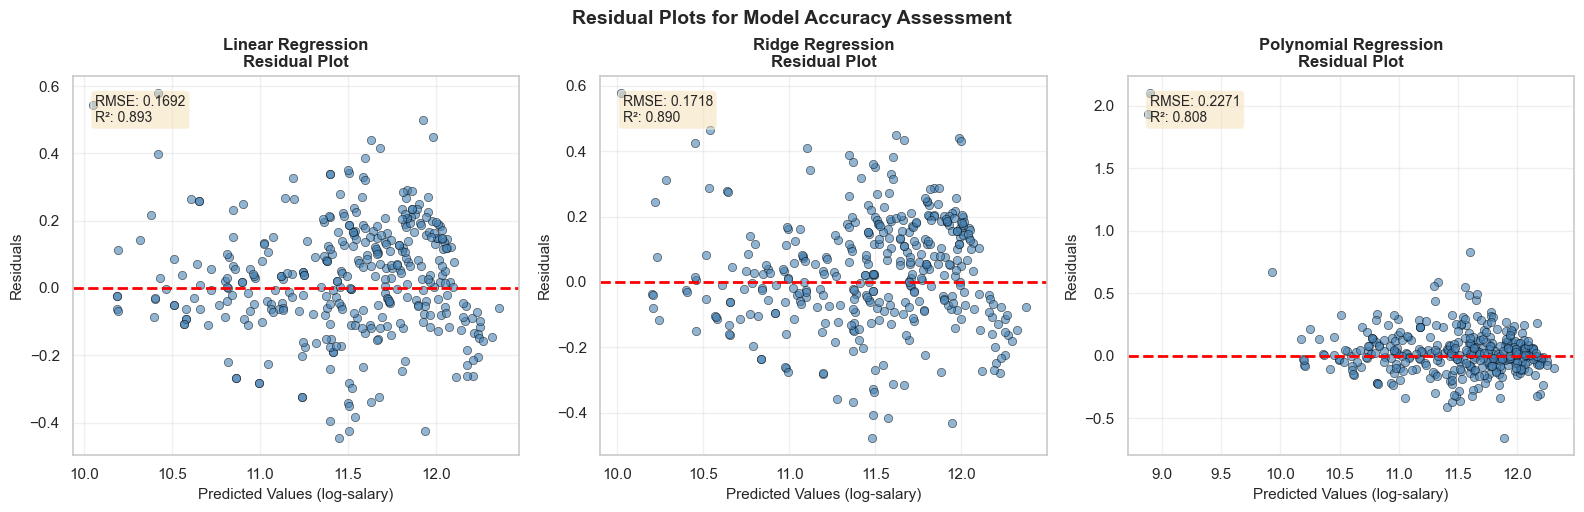


RESIDUAL ANALYSIS - MODEL ACCURACY

Linear Regression:
  Mean of residuals: 0.030063 (should be close to 0)
  Std of residuals: 0.166778
  Min residual: -0.446044
  Max residual: 0.579420

Ridge Regression:
  Mean of residuals: 0.031907 (should be close to 0)
  Std of residuals: 0.169018
  Min residual: -0.477645
  Max residual: 0.578270

Polynomial Regression:
  Mean of residuals: 0.034419 (should be close to 0)
  Std of residuals: 0.224776
  Min residual: -0.659189
  Max residual: 2.102287


In [ ]:
# Residual Plot - Model Accuracy Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Calculate residuals for each model
residuals_linear = Y_test - y_predict_li
residuals_ridge = Y_test - y_predict_ri
residuals_poly = Y_test - y_predict_po

models = ['Linear Regression', 'Ridge Regression', 'Polynomial Regression']
predictions = [y_predict_li, y_predict_ri, y_predict_po]
residuals_list = [residuals_linear, residuals_ridge, residuals_poly]

# Plot residuals vs predicted values
for idx, (ax, model_name, y_pred, residuals) in enumerate(
    zip(axes, models, predictions, residuals_list)
):
    ax.scatter(
        y_pred,
        residuals,
        alpha=0.6,
        color='steelblue',
        edgecolor='black',
        linewidth=0.5,
    )
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Values (log-salary)', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(f'{model_name}\nResidual Plot', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Calculate and display RMSE and R2 for reference
    rmse = root_mean_squared_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)
    ax.text(
        0.05,
        0.95,
        f'RMSE: {rmse:.4f}\nR²: {r2:.3f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10,
    )

plt.tight_layout()
plt.suptitle(
    'Residual Plots for Model Accuracy Assessment',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.show()

print("\n" + "=" * 60)
print("RESIDUAL ANALYSIS - MODEL ACCURACY")
print("=" * 60)
for model_name, residuals in zip(models, residuals_list):
    print(f"\n{model_name}:")
    print(f"  Mean of residuals: {residuals.mean():.6f} (should be close to 0)")
    print(f"  Std of residuals: {residuals.std():.6f}")
    print(f"  Min residual: {residuals.min():.6f}")
    print(f"  Max residual: {residuals.max():.6f}")

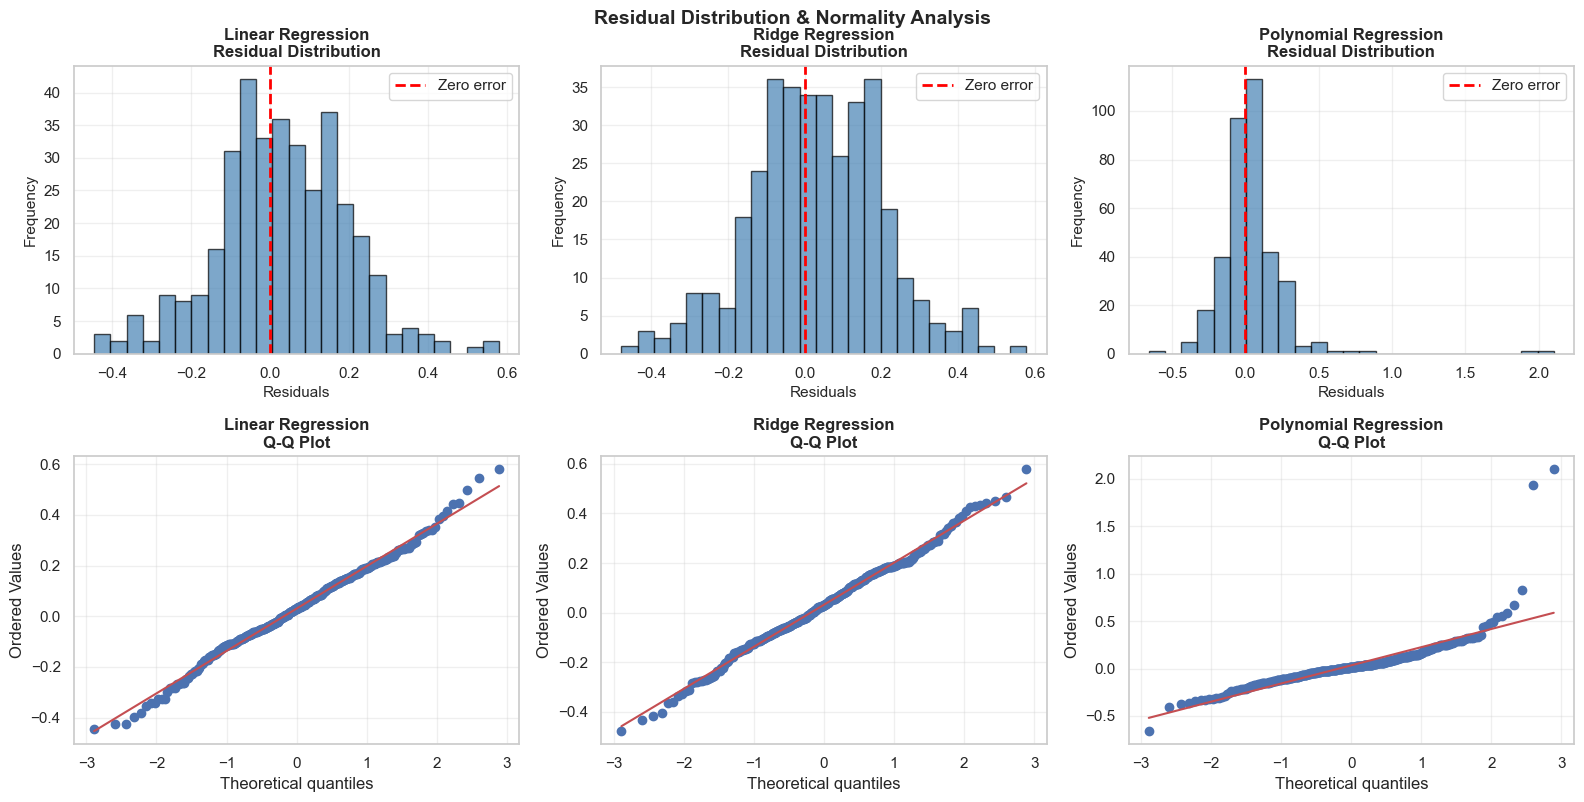


NORMALITY TEST - RESIDUALS (Shapiro-Wilk Test)
H0: Residuals are normally distributed
If p-value > 0.05, residuals are likely normally distributed

Linear Regression:
  Test Statistic: 0.994125
  P-value: 0.181509
  Result: Residuals are normally distributed ✓

Ridge Regression:
  Test Statistic: 0.995467
  P-value: 0.383881
  Result: Residuals are normally distributed ✓

Polynomial Regression:
  Test Statistic: 0.730134
  P-value: 0.000000
  Result: Residuals deviate from normality



In [ ]:
# Residual Distribution Analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for idx, (model_name, residuals) in enumerate(zip(models, residuals_list)):
    # Histogram
    ax_hist = axes[0, idx]
    ax_hist.hist(residuals, bins=25, alpha=0.7, color='steelblue', edgecolor='black')
    ax_hist.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
    ax_hist.set_xlabel('Residuals', fontsize=11)
    ax_hist.set_ylabel('Frequency', fontsize=11)
    ax_hist.set_title(
        f'{model_name}\nResidual Distribution', fontsize=12, fontweight='bold'
    )
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # Q-Q Plot (to check normality)
    from scipy import stats

    ax_qq = axes[1, idx]
    stats.probplot(residuals, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{model_name}\nQ-Q Plot', fontsize=12, fontweight='bold')
    ax_qq.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(
    'Residual Distribution & Normality Analysis', fontsize=14, fontweight='bold', y=1.00
)
plt.show()

print("\n" + "=" * 60)
print("NORMALITY TEST - RESIDUALS (Shapiro-Wilk Test)")
print("=" * 60)
print("H0: Residuals are normally distributed")
print("If p-value > 0.05, residuals are likely normally distributed\n")

for model_name, residuals in zip(models, residuals_list):
    stat, p_value = stats.shapiro(residuals)
    print(f"{model_name}:")
    print(f"  Test Statistic: {stat:.6f}")
    print(f"  P-value: {p_value:.6f}")
    print(
        f"  Result: {'Residuals are normally distributed ✓' if p_value > 0.05 else 'Residuals deviate from normality'}\n"
    )